(sec:dimer-case1-qme)=
# QME: Numerical analysis

Using the Hamiltonian {eq}`eq:dimer-case1-hamiltonian` and the disspator {eq}`eq:dimer-case1-dissipator`, we solve the quantum master equation using `QuTiP`.

## Steady state


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qutip import *

# Parameters
omega0 = 1.0
gamma0 = 0.1   # spontaneous emission rate
temperature = 1.0  # tempeature of photon gas
NT = 1/(np.exp(omega0/temperature)-1) # Planck distribution

gamma_a = gamma0 * NT   # coefficient to absorption
gamma_e = gamma0 * (NT+1)  # coefficient to emission

i2 = qeye(2)
sz = [tensor(sigmaz(),i2),tensor(i2,sigmaz())]
sp = [tensor(sigmap(),i2),tensor(i2,sigmap())]
sm = [tensor(sigmam(),i2),tensor(i2,sigmam())]

# Hamiltonian
H = 0.5*omega0*(sz[0]+sz[1])

# Collapse operators
c_ops = [np.sqrt(gamma_a)*sp[0], np.sqrt(gamma_a)*sp[1],np.sqrt(gamma_e)*sm[0], np.sqrt(gamma_e)*sm[1]]

# Liouvillian
L = liouvillian(H,c_ops)

# Steady state
rho_ss = steadystate(L)

print("*** Steady state ***")
print("total system")
print(rho_ss.full())
print("subsystem 1")
print(rho_ss.ptrace(0).full())
print("subsystem 2")
print(rho_ss.ptrace(1).full())

*** Steady state ***
total system
[[ 0.07232949+0.j  0.        +0.j  0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.19661193+0.j -0.        +0.j  0.        +0.j]
 [ 0.        +0.j -0.        +0.j  0.19661193+0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j  0.53444665+0.j]]
subsystem 1
[[0.26894142+0.j 0.        +0.j]
 [0.        +0.j 0.73105858+0.j]]
subsystem 2
[[0.26894142+0.j 0.        +0.j]
 [0.        +0.j 0.73105858+0.j]]


Let us check if cross correlation indeed vanishes as we assumed.  The followinfg code confirms it.

In [2]:
x=expect(sp[0]*sm[0],rho_ss)
print("<sigma+_1 sigma-_1> = ",x)
x=expect(sp[1]*sm[1],rho_ss)
print("<sigma+_2 sigma-_2> = ",x)
x=expect(sp[0]*sm[1],rho_ss)
print("<sigma+_1 sigma-_2> = ",x)

<sigma+_1 sigma-_1> =  0.2689414213699951
<sigma+_2 sigma-_2> =  0.2689414213699951
<sigma+_1 sigma-_2> =  0j


## Second-order coherence function

The coherence function measured by a detector does not depend on the location as shown in Eq. {eq}`eq:g2-dimer-incoherent`.  It is the same as emission counting without interference.  Nevertheless, $g^{(2)}(\tau)$ from the incoherent pair is not the same as that of a single emitter.  The no-delay coherence is $g^{(2)}(0)=0.5$ instead of $0$ as predicted by Eq. {eq}`g2-incoherent-N`, suggesting that there is a good chance that two photons arrive at the same time.  When a photon emitted by the first emitter, the same emitter can't emit another photon immediately.  However, another photon from the second emitter can arrive at the same time as the first one since the two photons emitted by different emitters are not independent from each other.  The following code clearly shows it. 

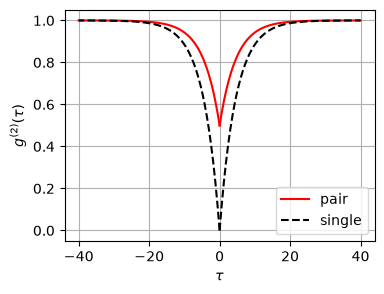

In [3]:
times = np.linspace(0, 40, 400)

G2 = np.zeros_like(times, dtype=complex)

for i in range(2):
    for j in range(2):
        G2 += correlation_3op_1t(H,rho_ss,times,c_ops,sp[i],sp[j]*sm[j],sm[i],solver="me")
        
# normalize the correlation 
# mean intensity of steady state
I_sum = expect(sp[0]*sm[0]+sp[1]*sm[1],rho_ss)
g2 = G2/I_sum**2

g2_exact = 1-np.exp(-(gamma_a+gamma_e)*times)

plt.figure(figsize=(4,3))
plt.plot(times, np.real(g2),c='r',label="pair")
plt.plot(-times,np.real(g2),c='r')
plt.plot(times, np.real(g2_exact),c='k',ls='--',label="single")
plt.plot(-times, np.real(g2_exact),c='k',ls='--')
plt.xlabel(r'$\tau$')
plt.ylabel(r'$g^{(2)}(\tau)$')
plt.legend(loc=4)
plt.grid(True)
plt.show()
